In [1]:
!pip install scikit-learn

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [3]:
print("Downloading MNIST dataset...")

mnist = fetch_openml('mnist_784', version=1)

X = mnist.data.values / 255.0
y = mnist.target.astype(int).values.reshape(-1,1)

print(X.shape)
print(y.shape)

(70000, 784)
(70000, 1)


In [5]:
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(56000, 784)
(14000, 784)


In [7]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return x > 0

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

In [8]:
input_size = 784
hidden1 = 128
hidden2 = 64
output_size = 10

In [9]:
W1 = np.random.randn(input_size, hidden1) * 0.01
b1 = np.zeros((1, hidden1))

W2 = np.random.randn(hidden1, hidden2) * 0.01
b2 = np.zeros((1, hidden2))

W3 = np.random.randn(hidden2, output_size) * 0.01
b3 = np.zeros((1, output_size))

In [10]:
learning_rate = 0.01
epochs = 20

for epoch in range(epochs):

    Z1 = np.dot(X_train, W1) + b1
    A1 = relu(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = relu(Z2)

    Z3 = np.dot(A2, W3) + b3
    A3 = softmax(Z3)

    loss = -np.mean(y_train * np.log(A3 + 1e-8))

    # Backpropagation
    dZ3 = A3 - y_train
    dW3 = np.dot(A2.T, dZ3)
    db3 = np.sum(dZ3, axis=0, keepdims=True)

    dA2 = np.dot(dZ3, W3.T)
    dZ2 = dA2 * relu_derivative(Z2)
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = np.dot(X_train.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # Update weights
    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    print("Epoch", epoch+1, "Loss:", loss)

Epoch 1 Loss: 0.23025845556846336
Epoch 2 Loss: 0.5992332961095036
Epoch 3 Loss: 1.6591770297667099
Epoch 4 Loss: 1.635637829171674
Epoch 5 Loss: 1.6355919795870957
Epoch 6 Loss: 1.284560382023801
Epoch 7 Loss: 1.2257444924400442
Epoch 8 Loss: 1.6622003638364793
Epoch 9 Loss: 1.5561561760552054
Epoch 10 Loss: 1.5795025393148827
Epoch 11 Loss: 1.6599006993677576
Epoch 12 Loss: 1.6575323261279642
Epoch 13 Loss: 1.661808555584888
Epoch 14 Loss: 1.6543087069960223
Epoch 15 Loss: 1.651611391965969
Epoch 16 Loss: 1.6083410221108068
Epoch 17 Loss: 1.661166156749748
Epoch 18 Loss: 1.6594219360345859
Epoch 19 Loss: 1.659900699156194
Epoch 20 Loss: 1.6762819475923811


In [11]:
Z1 = np.dot(X_test, W1) + b1
A1 = relu(Z1)

Z2 = np.dot(A1, W2) + b2
A2 = relu(Z2)

Z3 = np.dot(A2, W3) + b3
A3 = softmax(Z3)

predictions = np.argmax(A3, axis=1)
true_labels = np.argmax(y_test, axis=1)

accuracy = np.mean(predictions == true_labels)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.09857142857142857


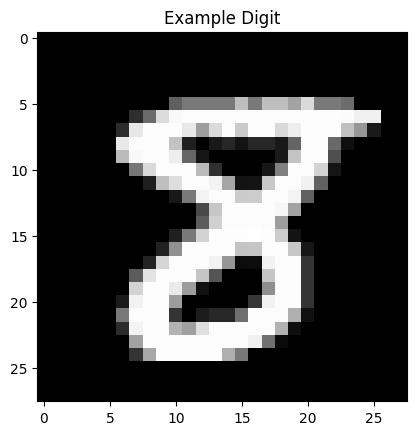

In [12]:
plt.imshow(X_test[0].reshape(28,28), cmap='gray')
plt.title("Example Digit")
plt.show()